# Extract simulated internal states 

These are not easily experimentally verified!

2025/06/13

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

In [2]:
# Calculate the density of the pure SEI components
rho_vc = 86.05 / 5.810e-5 * 1e-6 # Calculated from MW / Vm
rho_ec = 88.06 / 9.585e-5 * 1e-6 # Calculated from MW / Vm

rho_vc = 1.3 # From poly(VC) lit search
rho_ec = 1.6 # From LEDC lit search

In [21]:
# With optimal d_ec and d_vc values
d_ec_opt1 = 3.665e-20
d_vc_opt1 = 3.162e-17
d_ec_opt2 = 2.7e-20
d_vc_opt2 = 5.3e-17
d_ec_opt3 = 4.924e-20
d_vc_opt3 = 3.162e-17

to_simulate_cycling = False
to_simulate_form_aging = False

# df_sim1 = simutils.run_sim('base', 4.2e-20, 6.6e-18, dt=5, include_flag=2)
# df_sim2 = simutils.run_sim('fast', 4.2e-20, 6.6e-18, dt=5, include_flag=2)
# df_sim3 = simutils.run_sim('fast+', 4.2e-20, 6.6e-18, dt=1, include_flag=2)

df_sim1o = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, dt=1, include_flag=3)
df_sim2o = simutils.run_sim('fast', d_ec_opt1, d_vc_opt1, dt=1, include_flag=3)
df_sim3o = simutils.run_sim('fast+', d_ec_opt1, d_vc_opt1, dt=1, include_flag=3)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_32538/514025421.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig("outputs/figures/sei_summary_1p5_tuned_dsei.svg", format="svg")
/Users/ampere/.pyenv/versions/formation-modeling-env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/ampere/.pyenv/versions/formation-modeling-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


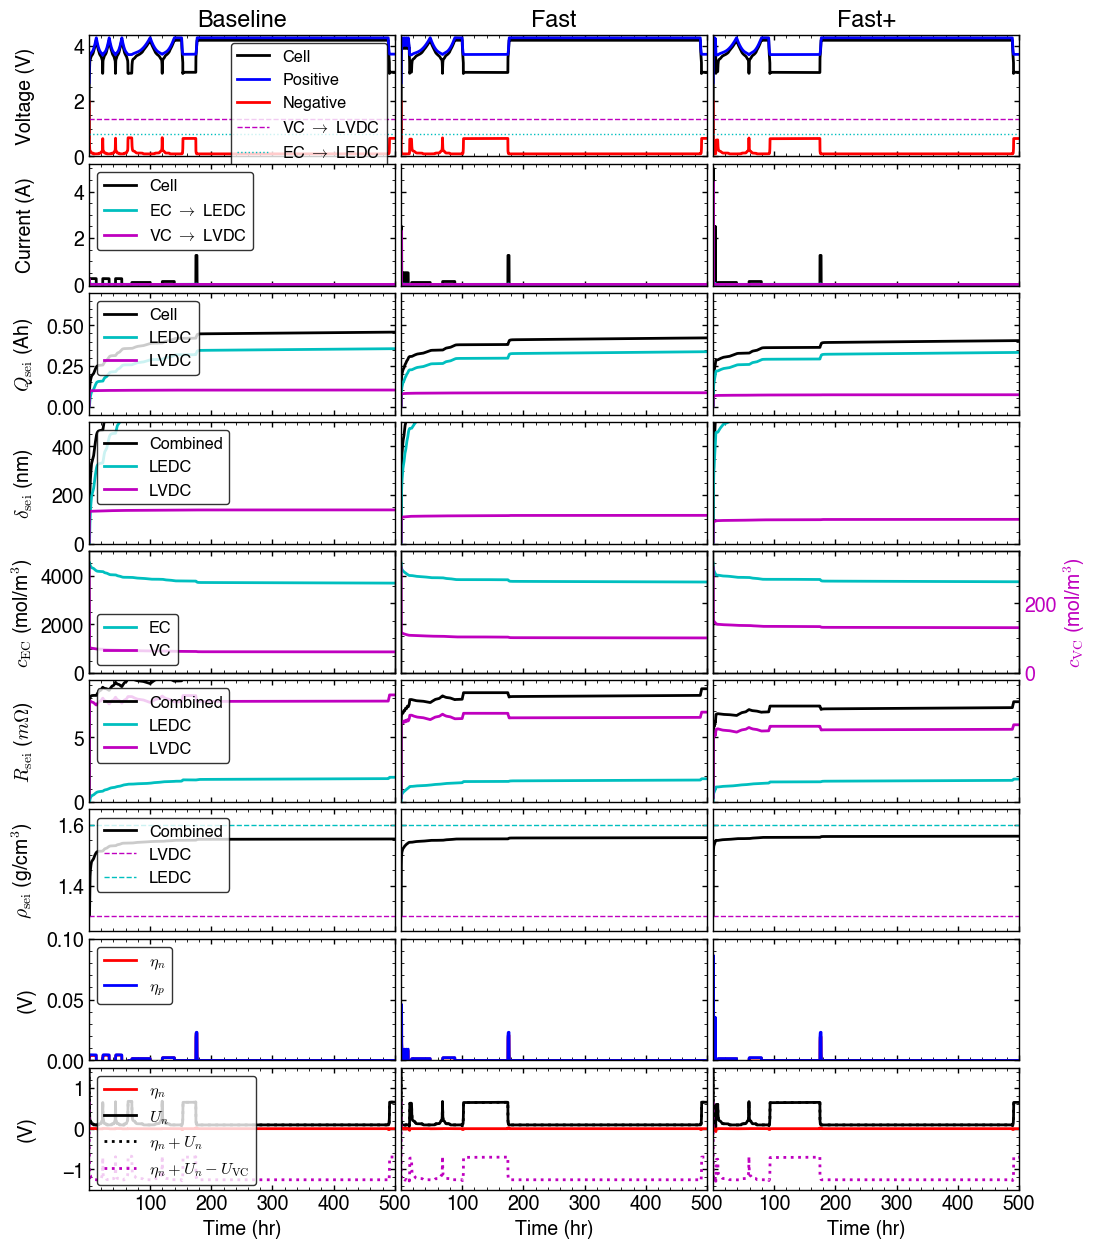

In [24]:
%matplotlib inline

fig, axes = plt.subplots(9, 3, figsize=(12, 15), sharex='col', 
                         gridspec_kw=dict(hspace=0.06, wspace=0.02))

# DataFrames and titles for columns
# dfs = [df_sim1, df_sim2, df_sim3]
dfso = [df_sim1o, df_sim2o, df_sim3o]
titles = ['Baseline', 'Fast', 'Fast+']

# Row labels and y-data
row_info = [
    ([('vt', 'Cell', 'k'),
      ('ocv_p', 'Positive', 'b'),
      ('ocv_n', 'Negative', 'r')], 'Voltage (V)', (0, 4.4)),
    ([('i_app', 'Cell', 'k'),
      ('i_sei1', r'EC $\rightarrow$ LEDC', 'c'),
      ('i_sei2', r'VC $\rightarrow$ LVDC', 'm')], 'Current (A)', (-0.05, 5.2)),
    ([('q_sei', 'Cell', 'k'),
      ('q_sei1', 'LEDC', 'c'),
      ('q_sei2', 'LVDC', 'm')], r'$Q_{\mathrm{sei}}$ (Ah)', (-0.05, 0.7)),
    ([('delta_sei', 'Combined', 'k'),
      ('delta_sei1', 'LEDC', 'c'),
      ('delta_sei2', 'LVDC', 'm')], r'$\delta_{\mathrm{sei}}$ (nm)', (0, 0.5e-6)),
    ([('c_sei1', 'EC', 'c')], r'$c_{\mathrm{EC}}$ (mol/m$^3$)', (0, 5000)),
    ([('R_sei', 'Combined', 'k'),
      ('R_sei1', 'LEDC', 'c'),
      ('R_sei2', 'LVDC', 'm')], r'$R_{\mathrm{sei}}$ ($m\Omega$)', (0, 0.0094)),
    ([('rho_sei', 'Combined', 'k')], r'$\rho_{\mathrm{sei}}$ (g/cm$^3$)', (1.25, 1.65)),
    ([('eta_n', r'$\eta_n$', 'r'),
      ('eta_p', r'$\eta_p$', 'b')], r'(V)', (0, 0.1)),
    ([('eta_n', r'$\eta_n$', 'r'),
      ('ocv_n', r'$U_n$', 'k')], r'(V)', (-1.5, 1.5))
]

for col, (df, title) in enumerate(zip(dfso, titles)):
    for row, (yinfo, ylabel, ylim) in enumerate(row_info):

        ax = axes[row, col]
        ax.set_ylim(ylim)

        for _, (key, label, color) in enumerate(yinfo):
            ax.plot(df['t']/3600, df[key], label=label, color=color)

        if col == 0:
            ax.set_ylabel(ylabel)


        if row == 0: # VOLTAGE
            ax.axhline(1.35, color='m', linestyle='--', linewidth=1, label=r'VC $\rightarrow$ LVDC')
            ax.axhline(0.8, color='c', linestyle=':', linewidth=1, label=r'EC $\rightarrow$ LEDC')
            ax.set_title(title)

        if row == 1: # CURRENT
            pass
            # ax.set_yscale('log')

        if row == 3: # SEI THICKNESS
            for line in ax.get_lines():
                line.set_ydata(line.get_ydata() * 1e9)
                ax.set_ylim(ylim[0] * 1e9, ylim[1] * 1e9)

        if row == 4: # SEI CONCENTRATION
            # Plot VC (c_sei2) on a secondary y-axis
            ax2 = ax.twinx()
            ax2.plot(df['t']/3600, df['c_sei2'], color='m', label='VC', linestyle='-')
            
            ax2.set_ylabel(r'$c_{\mathrm{VC}}$ (mol/m$^3$)', color='m')
            ax2.tick_params(axis='y', labelcolor='m')
            ax2.set_ylim(0, 350)
            ax2.grid(False)

            if col != axes.shape[1] - 1:
                ax2.set_yticklabels([])
                ax2.set_ylabel('')

            if col == 0: 
                # Combine legends from both axes
                lines, labels = ax.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                ax2.legend(lines + lines2, labels + labels2, loc='lower left',
                        fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')

        if row == 5: # SEI RESISTANCE
            for line in ax.get_lines():
                line.set_ydata(line.get_ydata() * 1e3)
                ax.set_ylim(ylim[0] * 1e3, ylim[1] * 1e3)
    
        if row == 6: # DENSITY
            ax.axhline(rho_vc, color='m', linestyle='--', linewidth=1, label='LVDC')
            ax.axhline(rho_ec, color='c', linestyle='--', linewidth=1, label='LEDC')

        if row == 8: # NEGATIVE OVERPOTENTIAL
            ax.plot(df['t']/3600, df['eta_n'] + df['ocv_n'], color='k', label=r'$\eta_n + U_n$', ls=':')
            ax.plot(df['t']/3600, df['eta_n'] + df['ocv_n'] - 1.35, color='m', label=r'$\eta_n + U_n - U_\mathrm{VC}$', ls=':')
            ax.set_xlabel('Time (hr)')

        # Only add legend for the first column
        if col == 0 and row != 4:
            loc = 'upper right' if row == 0 else 'upper left'
            ax.legend(loc=loc, fontsize='small', frameon=True, 
                      facecolor=(1,1,1,0), edgecolor='black')
    

# Turn off grids in all subplots
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlim(0.4, 500)
        ax.grid(False)

# Only show y-axis markers on the left column
for col in range(1, axes.shape[1]):
    for row in range(axes.shape[0]):
        axes[row, col].set_yticklabels([])
        axes[row, col].set_ylabel('')

# Lock y-limits across each row
for row in range(axes.shape[0]):
    ymins, ymaxs = [], []
    for col in range(axes.shape[1]):
        ymins.append(axes[row, col].get_ylim()[0])
        ymaxs.append(axes[row, col].get_ylim()[1])
    ymin, ymax = min(ymins), max(ymaxs)
    for col in range(axes.shape[1]):
        axes[row, col].set_ylim(ymin, ymax)

fig.align_ylabels(axes[:, 0])

# plt.tight_layout()
# fig.subplots_adjust(hspace=0, wspace=0, 
                    # right=0.98, left=0.05, top=0.95, bottom=0.08)

# plt.show()
fig.savefig("outputs/figures/sei_summary_1p5_tuned_dsei.svg", format="svg")

It would be good if eta_n and eta_n+Un(theta_n)-Ui can be plotted. The first will show the kinetics on the anode directly and the second would tell when the j_rxn starts to have a non-zero value. (edited) 





